<a href="https://colab.research.google.com/github/Liily77/lydianeghad.github.io/blob/Portfolio/Projet_Deep_Learning_GTSRB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GTSRB - German Traffic Sign Recognition Benchmark**

## **1️⃣ - Introduction**


Le German Traffic Sign Recognition Benchmark (GTSRB) est un dataset de référence utilisé dans la classification automatique des panneaux de signalisation.

Avec l’essor des voitures autonomes et des systèmes d’aide à la conduite, il devient de plus en plus important de pouvoir identifier correctement les panneaux de signalisation. Ces panneaux jouent un rôle clé dans **la régulation du trafic** et **la sécurité des usagers**. Si un véhicule ou un système d’assistance ne les interprète pas correctement, cela peut entraîner des erreurs de conduite, comme un dépassement de vitesse involontaire ou un non-respect d’un stop. C’est pourquoi développer un modèle capable de reconnaître et classer automatiquement ces panneaux est essentiel pour assurer une **conduite plus sûre** et mieux **adaptée aux réglementations en vigueur**.

Le dataset GTSRB contient :

- Plus de 50 000 images de panneaux routiers prises dans différentes conditions.
- 43 classes différentes, représentant divers types de panneaux (limitation de vitesse, interdictions, dangers, etc.).
- Des images avec des variations d'éclairage, d’angles et de qualité, rendant la tâche plus proche des conditions réelles sur la route.

**1. Panneaux de limitation de vitesse**

- Ces panneaux indiquent la vitesse maximale autorisée sur une portion de route.
- Exemples : 30 km/h, 50 km/h, 80 km/h, 120 km/h…

**2. Panneaux d’interdiction**
- Ils signalent des actions interdites aux conducteurs.
- Exemples : Sens interdit, interdiction de dépasser, interdiction de tourner…

**3. Panneaux de danger**
- Ils avertissent d’un danger potentiel sur la route.
- Exemples : Route glissante, travaux, passage piéton, virage dangereux…

**4. Panneaux d’obligation**
- Ils imposent un comportement aux conducteurs.
- Exemples : Obligation de tourner à gauche, passage obligatoire, port de chaînes à neige…

**5. Panneaux de priorité**
- Ils régulent les priorités et les intersections.
- Exemples : Stop, cédez-le-passage, priorité à droite, fin de priorité…

# **2️⃣ - Préparation des données**

## **◾ Charger et explorer le dataset GTSRB**

In [33]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/Kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot create regular file '/root/.kaggle/': Not a directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [34]:
import os

dataset_path = "gtsrb_dataset"

if not os.path.exists(dataset_path):
    print("Téléchargement du dataset GTSRB...")
    !kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign --force
    print("Extraction du dataset...")
    !unzip gtsrb-german-traffic-sign.zip -d gtsrb_dataset > /dev/null  # Extraction silencieuse
    print("Dataset téléchargé et extrait avec succès.")
else:
    print("Le dataset est déjà présent, aucune action nécessaire.")


Le dataset est déjà présent, aucune action nécessaire.


### **Importations**

In [35]:
# Installer les bibliothèques nécessaires (uniquement si elles ne sont pas déjà installées)
!pip install --quiet opencv-python-headless matplotlib seaborn tensorflow scikit-learn scikeras


In [36]:
import os
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Traitement des images
import cv2
from PIL import Image

# Préparation des données et division en ensembles
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Construction du modèle CNN
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier




# Évaluation du modèle
from sklearn.metrics import classification_report, confusion_matrix
import itertools


### **Structure du dataset**

In [37]:
# Dossier principal
dataset_path = "gtsrb_dataset/train"

print("Contenu du dossier train :")
print(os.listdir(dataset_path))


Contenu du dossier train :
['34', '6', '8', '18', '22', '13', '20', '25', '24', '5', '41', '29', '12', '4', '39', '30', '17', '31', '15', '23', '7', '35', '40', '36', '11', '9', '42', '21', '19', '33', '27', '16', '3', '28', '0', '38', '32', '2', '10', '37', '1', '14', '26']


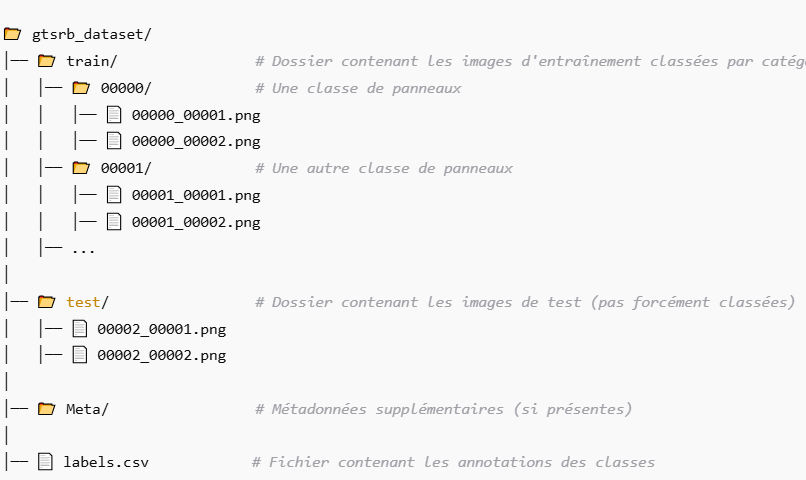

### **Chargement et exploration du dataset GTSRB**

### **Prétraitement des images et division du dataset**

In [38]:
# Définition de la taille des images
IMG_SIZE = (32, 32)

dataset_path = "gtsrb_dataset/train"
image_paths = []
labels = []

# Récupération des chemins des images et des labels

for class_label, class_name in enumerate(sorted(os.listdir(dataset_path))):
    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image_paths.append(img_path)
            labels.append(class_label)

# Chargement des images et prétraitement
X, y = [], []
for img_path, label in zip(image_paths, labels):
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')  # Conversion en RGB
        img = img.resize(IMG_SIZE)  # Redimensionnement
        X.append(np.array(img))  # Conversion en tableau NumPy
        y.append(label)

# Conversion en tableaux NumPy et normalisation
X = np.array(X) / 255.0  # Normalisation des pixels
y = np.array(y)
y = to_categorical(y, num_classes=len(set(y)))  # Encodage one-hot des labels

print("Shape du dataset:", X.shape, y.shape)

Shape du dataset: (39209, 32, 32, 3) (39209, 43)


### **Augmentation des données**

In [39]:
# Définition de l'augmentation des données
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

datagen.fit(X_train)  # Application de l'augmentation uniquement sur l'entraînement

# Affichage des dimensions des ensembles
print("Ensemble d'entraînement:", X_train.shape, y_train.shape)
print("Ensemble de test:", X_test.shape, y_test.shape)





Ensemble d'entraînement: (31367, 32, 32, 3) (31367, 43)
Ensemble de test: (7842, 32, 32, 3) (7842, 43)


# **3️⃣ - Conception et implémentation du modèle CNN**

Construire un modèle CNN pour la classification des panneaux de
signalisation.

## **◾ Implémentation d’un Modèle CNN Simple**

In [42]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(43, activation='softmax')
])

model.summary()
#Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 43)                  │           2,795 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169,707 (662.92 KB)

 Trainable params: 169,707 (662.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=64)

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.2993 - loss: 2.6951 - val_accuracy: 0.8540 - val_loss: 0.5901
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.8128 - loss: 0.6381 - val_accuracy: 0.9434 - val_loss: 0.2653
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.8997 - loss: 0.3489 - val_accuracy: 0.9606 - val_loss: 0.1637
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.9270 - loss: 0.2457 - val_accuracy: 0.9742 - val_loss: 0.1070
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.9438 - loss: 0.1853 - val_accuracy: 0.9702 - val_loss: 0.1046
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9539 - loss: 0.1545 - val_accuracy: 0.9801 - val_loss: 0.0763
Epoch 7/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9631 - loss: 0.1246 - val_accuracy: 0.9830 - val_loss: 0.0586
Epoch 8/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.9670 - loss: 0.1073 - 

In [40]:
# Définition du modèle CNN amélioré
model = Sequential()

# Première couche de convolution
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', kernel_regularizer=l2(0.03), input_shape=(32,32,3)))
model.add(BatchNormalization())

# Deuxième couche de convolution
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(0.03)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.3))

# Troisième couche de convolution
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(0.03)))  # Augmentation des filtres
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.3))

# Quatrième couche de convolution (nouvelle)
#model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', kernel_regularizer=l2(0.03)))
#model.add(BatchNormalization())
#model.add(MaxPooling2D(pool_size=(2,2)))
#model.add(Dropout(rate=0.4))

# Aplatir les données pour la Fully Connected
model.add(Flatten())

# Couche Fully Connected avec régularisation L2
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.02)))
model.add(Dropout(rate=0.4))

# Couche de sortie (43 classes pour GTSRB)
model.add(Dense(y.shape[1], activation='softmax'))


model.compile(
    loss='categorical_crossentropy',
    optimizer="adam",
    metrics=['accuracy']
)


model.summary()

# éviter l'overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,  # Arrêt si pas d'amélioration pendant 6 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Réduction du learning rate par 2 si la loss ne s'améliore pas
    patience=3,
    min_lr=1e-6
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 32)          │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 26, 26, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 26, 26, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 11, 11, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 11, 11, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │         204,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 43)                  │           2,795 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 303,339 (1.16 MB)

 Trainable params: 302,891 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

# **4️⃣ - Entraînement du modèle**

Nous allons observer l'évolution de la précision (accuracy) et de la perte (loss) pour s'assurer que le modèle apprend efficacement sans sur-apprentissage.

### **Avec augmentation de données**

### **Sans augmentation**

# **5️⃣ - Evaluation du modèle**

### **Prédictions sur le jeu de test**

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

### **Calcul des métriques de performance**

In [ ]:
report = classification_report(y_true, y_pred, target_names=[str(i) for i in range(num_classes)])
print("Rapport de classification :\n", report)
